# Tutorial for running the Python Inverse Problem Toolbox (PIPT)

<font size=4em>As an illustrative example we choose a small 3D-field with three producers and three (water) injectors. The figure below shows the true (data generating) permeability field and the well positions. The grid is 10x10x2, and the porosity is 0.2. The inverse problem is to find the permeability for the reservoir by assimilation produced water and oil and injected water. 

<img src="../permx.png?lastmod=12345678" alt="drawing" width="500"/>
<br>
<font size=4em>The first step is to load neccessary external and local modules. 

In [1]:
# Import global modules
import numpy as np

# Import local modules
from pipt import ESMDA # the assimilation scheme; it owns its own iteration loop
from subsurface.multphaseflow.opm import flow # the simulator we want to use
from input_output import read_config # the config reader
from pipt.pipt_init import init_da

<font size=4em>Set the random seed:

In [2]:
np.random.seed(10)

<font size=4em>Read inputfile. In this tutorial the input file is written as a .toml file, and consists of two main keys: <span style="font-family:Courier;">dataassim</span> and <span style="font-family:Courier;">fwdsim</span>. The first part contains the options for the data assimilation algorithm and the second part are options related to the forward simulation model. The description of all keys are provided in the printouts of method docstrings below.

In [3]:
!cat CONFIG_ESMDA.toml
kwda, kwsim, kwens = read_config.read('CONFIG_ESMDA.toml')
# kwda  -->  Data assimilation settings
# kwsim -->  Simulator settings
# kwens -->  Ensemble settings

[ensemble]
    ne = 50
    state = "permx"
    [ensemble.prior_permx]
        vario = "sph"
        mean  = "priormean.npz"
        var   = 1.0
        range = 10.0
        aniso = 1.0
        angle = 0.0
        grid  = [10, 10, 2]

[dataassim]
    savefolder = "Results"
    scheme     = "esmda"
    analysis   = "approx"
    energy     = 98.0
    obsname    = "dates"
    data       = "data.csv"
    datavar    = "var.csv"
    savedata   = ["ensemble_misfit"]

    # ESMDA settings
    [dataassim.mda]
        tot_assim_steps = 5
        inflation_param = [5, 5, 5, 5, 5]
    
    
[simulator]
    reporttype  = "dates"
    reportpoint = [
        2023-02-05T00:00:00,
        2024-03-11T00:00:00,
        2025-04-15T00:00:00,
        2026-05-20T00:00:00,
        2027-06-24T00:00:00,
        2028-07-28T00:00:00,
        2029-09-01T00:00:00,
        2030-10-06T00:00:00,
        2031-11-10T00:00:00,
        2032-12-14T00:00:00,
    ]
    sim_limit = 300.0
    runfile   = "RUNFILE"
    parallel 

<font size=4em>Example using ESMDA. The input and available options are given below. During assimilation, useful information is written to the screen. The same information is also written to a log-file named pet_logger.log. 

In [4]:
# There are different ways to run the assimilation. Here are three examples:

# Option 1: Use the ESMDA class method directly
sim = flow(kwsim)
res = ESMDA.assimilate(kwda, kwens, sim)

# Option 2: Create an instance of the ESMDA class and run the assimilation loop
# emsda = ESMDA(kwda, kwens, sim)
# res = emsda.run_assimilation()

# Option 3: Use the init_da function to initialize the ESMDA instance and run the assimilation loop
# esmda = init_da(kwda, kwens, sim)
# res = esmda.run_assimilation()

print(f'data misfit: {res.prior_data_misfit:.1f} -> {res.data_misfit:.1f}')
print(res)


2026-08-20│13:58:11 :  =========== Running Data Assimilation - ESMDA ===========


Single entry for VARIO will be copied to all 2 layers
Single entry for VARIANCE will be copied to all 2 layers
Single entry for ANISO will be copied to all 2 layers
Single entry for ANGLE will be copied to all 2 layers
Single entry for CORR_LENGTH will be copied to all 2 layers


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-20│13:59:11 : 


2026-08-20│13:59:11 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐


...

2026-08-20│14:04:14 : 


2026-08-20│14:04:14 : Maximum iterations reached without convergence.


2026-08-20│14:04:14 :  
 Convergence was met. Obj. function reduced from 112592494809.9 to 756.9


2026-08-20│14:04:14 :  Assimilation finished after 5 iteration(s): Maximum number of iterations reached


data misfit: 112592494809.9 -> 756.9
           message: Maximum number of iterations reached
           success: False
                 x: [[ 5.005e+00  4.575e+00 ...  4.212e+00  4.571e+00]
                     [ 5.566e+00  5.149e+00 ...  4.610e+00  4.659e+00]
                     ...
                     [ 3.639e+00  4.104e+00 ...  4.006e+00  3.290e+00]
                     [ 3.713e+00  3.926e+00 ...  3.899e+00  3.496e+00]]
               nit: 5
          why_stop:  rel_data_misfit: 0.892187560800378
                         data_misfit: 756.8799657107337
                    prev_data_misfit: 7020.339872928015
       data_misfit: 756.8799657107337
 prior_data_misfit: 112592494809.87149


<font size=4em>Plot the data mismatch:

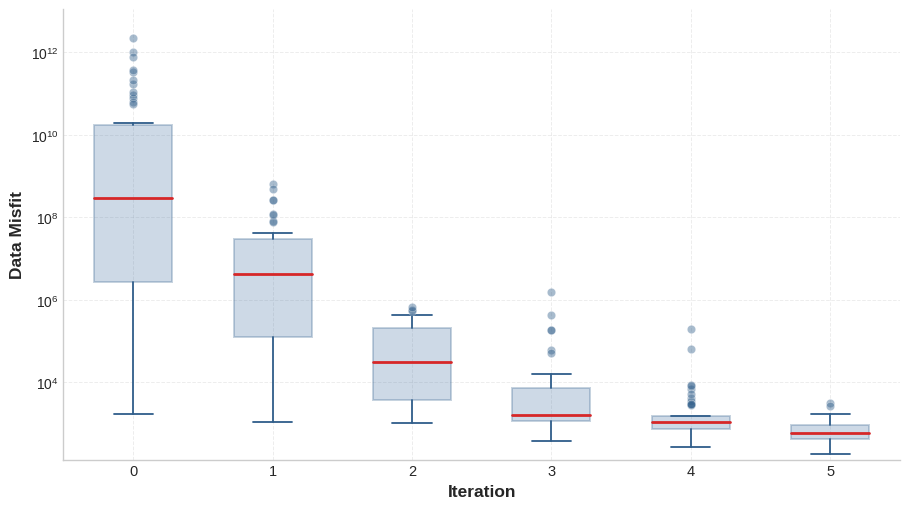

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

result_folder = "Results"
data_misfit = []

it = 0
while True:
    file = Path(f"{result_folder}/assimilation_result_{it}.npz")
    if not file.exists():
        break
    npzfile = np.load(file)
    data_misfit.append(npzfile["ensemble_misfit"])
    it += 1

# Make plot
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9.2, 5.2), facecolor="white")
bp = ax.boxplot(
    data_misfit,
    positions=range(len(data_misfit)),
    widths=0.56,
    patch_artist=True,
    showfliers=True,
    boxprops=dict(facecolor="#4C78A8", alpha=0.28, linewidth=1.4, edgecolor="#2F5D8A"),
    whiskerprops=dict(color="#2F5D8A", linewidth=1.3),
    capprops=dict(color="#2F5D8A", linewidth=1.3),
    medianprops=dict(color="#D62728", linewidth=2.0),
    flierprops=dict(marker="o", markersize=6, markerfacecolor="#2F5D8A",
                    markeredgecolor="white", markeredgewidth=0.4, alpha=0.42),
)

# Axis formatting
positions = range(len(data_misfit))
ax.set_xticks(positions)
ax.set_xticklabels([str(i) for i in positions], fontsize=10.5)
ax.set_xlabel("Iteration", fontsize=12.5, fontweight="semibold")
ax.set_ylabel("Data Misfit", fontsize=12.5, fontweight="semibold")
ax.set_yscale("log")
y_min = max(1e-12, np.nanmin([np.nanmin(s) for s in data_misfit]) * 0.75)
y_max = np.nanmax([np.nanmax(s) for s in data_misfit]) * 5
ax.set_ylim(y_min, y_max)
ax.grid(which="major", axis="both", linestyle="--", linewidth=0.7, alpha=0.35)
ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.45, alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()




<font size=4em>Plot the prior and posterior permeability in the upper layer:

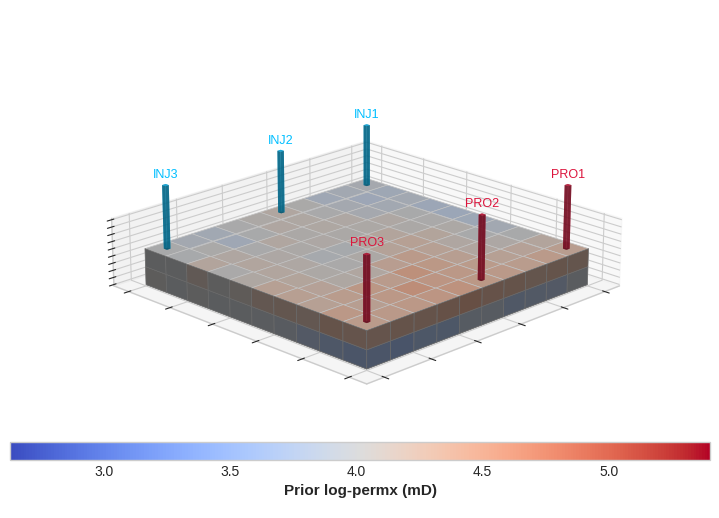

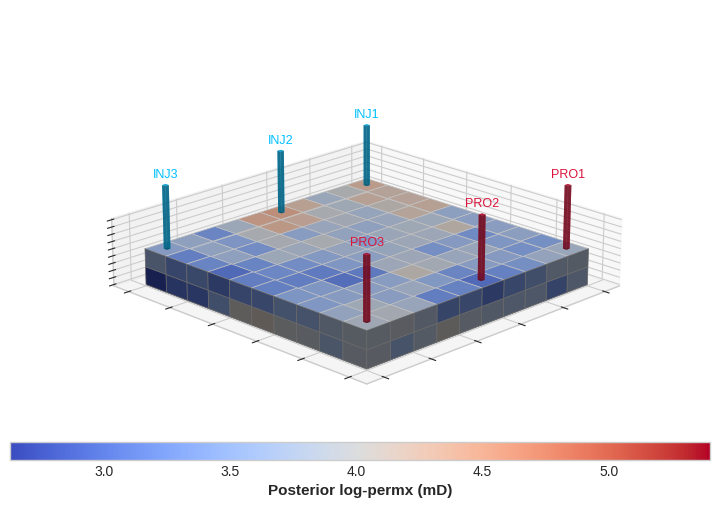

In [12]:
def plot_field(field, label, cmapname, cmax, cmin):
    nx, ny, nz = 10, 10, 2
    field = field.reshape((nx, ny, nz), order='F')

    wells = {
        "INJ1": {"ij": (0, 0), "color": "deepskyblue"},
        "INJ2": {"ij": (4, 0), "color": "deepskyblue"},
        "INJ3": {"ij": (9, 0), "color": "deepskyblue"},
        "PRO1": {"ij": (0, 9), "color": "crimson"},
        "PRO2": {"ij": (4, 9), "color": "crimson"},
        "PRO3": {"ij": (9, 9), "color": "crimson"},
    }

    # set max and min color
    cmap = plt.get_cmap(cmapname)
    norm = plt.Normalize(vmin=cmin, vmax=cmax)
    facecolors = cmap(norm(field))
    edgecolors = 'white'  # uniform edge color for all voxels

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.computed_zorder = False  # allow manual zorder in 3D
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.12)

    filled = np.ones((nx, ny, nz), dtype=bool)
    x, y, z = np.indices(np.array(filled.shape) + 1).astype(float)
    x = x / nx
    y = y / ny
    z = z / nz

    ax.voxels(
        x, y, z, filled,
        facecolors=facecolors,
        edgecolors=edgecolors,
        linewidth=0.5,
        alpha=1.0,
        zsort='max'
    )

    # Very thin, taller well sticks: centered in each cell
    stick_extra_above = 0.75      # taller above z=1.0 (was 0.30)
    stick_size_x = 0.15 / nx      # thinner
    stick_size_y = 0.15 / ny      # thinner

    for name, w in wells.items():
        i, j = w["ij"]
        color = w.get("color", "black")

        # exact cell center in normalized coordinates
        cx = (i + 0.5) / nx
        cy = (j + 0.5) / ny

        # bar3d expects lower-left corner, so shift by half size to keep centered
        ax.bar3d(
            cx - 0.5 * stick_size_x, cy - 0.5 * stick_size_y, 1.0,
            stick_size_x, stick_size_y, 1.0 + stick_extra_above,
            color=color, edgecolor=None, linewidth=0.8, shade=True, alpha=0.7, zsort='max',
        )
        ax.text(cx, cy, 1.0 + stick_extra_above + 1.2, name, color=color, fontsize=9, ha='center', zorder=1)

    ax.set_zlim(0.0, 1.0 + stick_extra_above + 0.05)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.03])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(label, fontsize=11, fontweight='bold')

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.view_init(elev=20, azim=45)
    ax.set_box_aspect([nx/10, ny/10, nz/10])

    plt.show()


# Plot prior and posterior fields (mean of ensemble)
prior_permx = np.load('Results/prior_ensemble.npz')['permx'].mean(axis=-1)
posterior_permx = np.load('Results/posterior_state_estimate.npz')['permx'].mean(axis=-1)
#posterior_permx = res.x.mean(axis=-1)
cmax = max(prior_permx.max(), posterior_permx.max())
cmin = min(prior_permx.min(), posterior_permx.min())
plot_field(prior_permx, label='Prior log-permx (mD)', cmapname='coolwarm', cmax=cmax, cmin=cmin)
plot_field(posterior_permx, label='Posterior log-permx (mD)', cmapname='coolwarm', cmax=cmax, cmin=cmin)

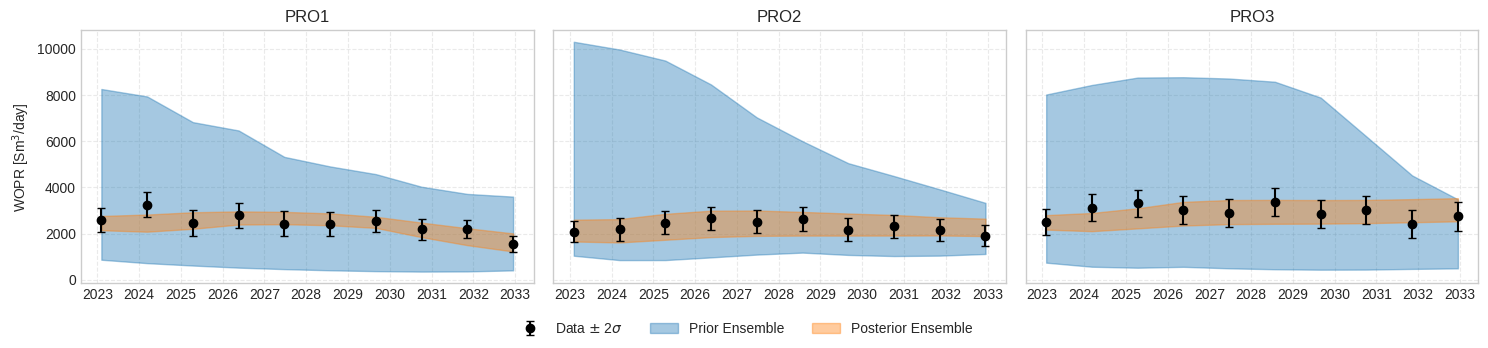

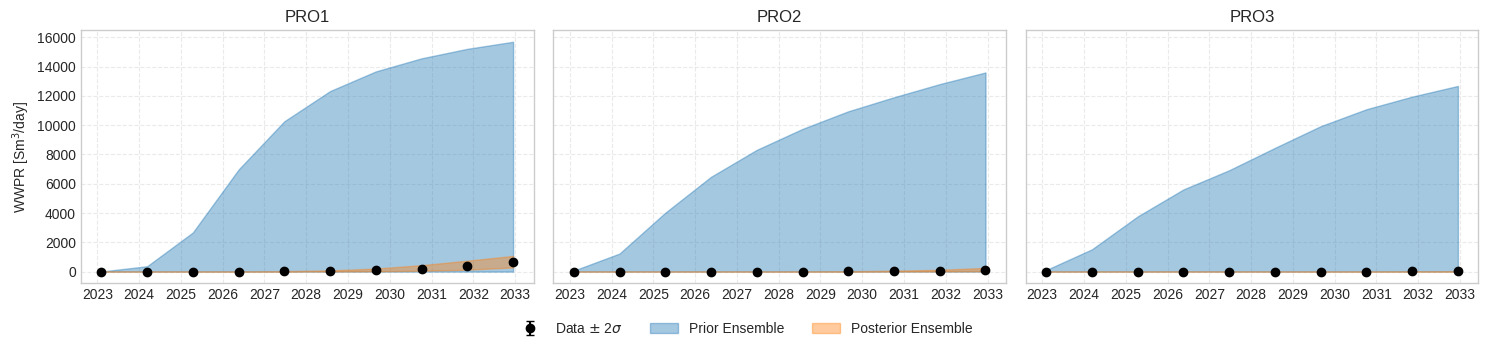

In [15]:
from misc.structures import PETDataFrame
from misc.read_input_csv import DataReader

# Data
datainfo = {'truedata': 'data.csv', 'datavar': 'var.csv'}
reader = DataReader(datainfo)
data = reader.get_data()
var  = reader.get_variance(data)
std  = np.sqrt(var)

# Prior and posterior forecasts
prior_forecast = PETDataFrame.from_pickle("Results/prior_forecast.pkl")
prior_forecast.is_ensemble = True

posterior_forecast = PETDataFrame.from_pickle("Results/posterior_forecast.pkl")
posterior_forecast.is_ensemble = True



def plot_rates(data, std, key, prior=None, post=None):
    wells = ['PRO1', 'PRO2', 'PRO3']

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5), sharex=True, sharey=True)

    handles, labels = [], []

    for i, well in enumerate(wells):

        h = ax[i].errorbar(
            data.index,
            data[f'{key}:{well}'],
            yerr=2 * std[f'{key}:{well}'],
            fmt='o',
            color='k',
            capsize=3,
            label=r'Data $\pm$ 2$\sigma$'
        )

        if i == 0:
            handles.append(h)
            labels.append(r'Data $\pm$ 2$\sigma$')

        if prior is not None:
            prior_ens = np.asarray(prior[f'{key}:{well}'].tolist())
            h = ax[i].fill_between(
                prior.index,
                prior_ens.min(axis=1),
                prior_ens.max(axis=1),
                color='tab:blue',
                alpha=0.4,
                label='Prior Ensemble'
            )
            if i == 0:
                handles.append(h)
                labels.append('Prior Ensemble')

        if post is not None:
            post_ens = np.asarray(post[f'{key}:{well}'].tolist())
            h = ax[i].fill_between(
                post.index,
                post_ens.min(axis=1),
                post_ens.max(axis=1),
                color='tab:orange',
                alpha=0.4,
                label='Posterior Ensemble'
            )
            if i == 0:
                handles.append(h)
                labels.append('Posterior Ensemble')

        ax[i].set_title(well)
        ax[i].grid(ls='--', alpha=0.4)

    ax[0].set_ylabel(rf'{key} [Sm$^3$/day]')

    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=len(labels),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


# Plot WOPR and WWPR
plot_rates(
    data=data,
    std=std,
    prior=prior_forecast,
    post=posterior_forecast,
    key='WOPR',
)

plot_rates(
    data=data,
    std=std,
    prior=prior_forecast,
    post=posterior_forecast,
    key='WWPR',
)







## A second scheme on the same case: GN-EnRML with the ``margis`` flavour

<font size=4em>ESMDA above is one scheme with one analysis flavour. PIPT separates the two: any of the five scheme classes (`EnKF`, `ES`, `ESMDA`, `LMEnRML`, `GNEnRML`) can be paired with any flavour it lists in its `COMPATIBLE_ANALYSES`. `GNEnRML` -- Gauss-Newton EnRML, damped by a step length `gamma` rather than ESMDA's fixed inflated schedule -- offers one flavour the others do not: `margis`, the marginalised iterative ensemble smoother of Stordal, Lorentzen & Fossum (2023), which treats the measurement-error variance itself as a hyperparameter and integrates it out rather than assuming it is known.

<font size=4em>Same grid, same wells, same prior, same observed data -- only the config's `scheme`/`analysis` keys and the `[dataassim.iteration]` block (GN-EnRML's step-length settings, in place of ESMDA's `[dataassim.mda]`) differ from `CONFIG_ESMDA.toml` above.


In [4]:
!cat CONFIG_GNENRML_MARGIS.toml
kwda, kwsim, kwens = read_config.read('CONFIG_GNENRML_MARGIS.toml')


[ensemble]
    ne = 50
    state = "permx"
    [ensemble.prior_permx]
        vario = "sph"
        mean  = "priormean.npz"
        var   = 1.0
        range = 10.0
        aniso = 1.0
        angle = 0.0
        grid  = [10, 10, 2]

[dataassim]
    savefolder = "Results_margis"
    scheme     = "gnenrml"
    analysis   = "margis"
    energy     = 98.0
    obsname    = "dates"
    data       = "data.csv"
    datavar    = "var.csv"
    savedata   = ["ensemble_misfit"]

    # GN-EnRML settings
    [dataassim.iteration]
        max_iter = 10
        gamma = 0.5
        gamma_factor = 5
        trunc_energy = 0.99


[simulator]
    reporttype  = "dates"
    reportpoint = [
        2023-02-05T00:00:00,
        2024-03-11T00:00:00,
        2025-04-15T00:00:00,
        2026-05-20T00:00:00,
        2027-06-24T00:00:00,
        2028-07-28T00:00:00,
        2029-09-01T00:00:00,
        2030-10-06T00:00:00,
        2031-11-10T00:00:00,
        2032-12-14T00:00:00,
    ]
    sim_limit = 300.0
    

<font size=4em>Run it the same way as ESMDA above -- the class changes, nothing else about the call does:


In [5]:
from pipt import GNEnRML

np.random.seed(10)
res_gn = GNEnRML.assimilate(kwda, kwens, flow(kwsim))

print(f'data misfit: {res_gn.prior_data_misfit:.1f} -> {res_gn.data_misfit:.1f}')
print(res_gn)


2026-08-20│15:03:43 :  =========== Running Data Assimilation - GNENRML ===========


Single entry for VARIO will be copied to all 2 layers
Single entry for VARIANCE will be copied to all 2 layers
Single entry for ANISO will be copied to all 2 layers
Single entry for ANGLE will be copied to all 2 layers
Single entry for CORR_LENGTH will be copied to all 2 layers


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-20│15:04:49 : 
2026-08-20│15:04:49 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
2026-08-20│15:04:49 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      γ      │
2026-08-20│15:04:49 :  ├─────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
2026-08-20│15:04:49 :  │      0      │   Success   │  1.126e+11  │             │  5.000e-01  │
2026-08-20│15:04:49 :  └─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘
2026-08-20│15:04:49 : 


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

...

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-20│15:16:01 : 
2026-08-20│15:16:01 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
2026-08-20│15:16:01 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      γ      │
2026-08-20│15:16:01 :  ├─────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
2026-08-20│15:16:01 :  │      9      │   Failed    │  5.838e+04  │    2.47     │  1.627e-01  │
2026-08-20│15:16:01 :  └─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘
2026-08-20│15:16:01 : 
2026-08-20│15:16:01 :  Data misfit increased! New Gamma for repeated analysis: 0.032540970760065305


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-20│15:17:01 : 
2026-08-20│15:17:01 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
2026-08-20│15:17:01 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      γ      │
2026-08-20│15:17:01 :  ├─────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
2026-08-20│15:17:01 :  │      9      │   Success   │  5.673e+04  │    -0.43    │  3.254e-02  │
2026-08-20│15:17:01 :  └─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘
2026-08-20│15:17:01 : 
2026-08-20│15:17:01 : Iterations have converged after 9 iterations. Objective function reduced from 112592494809.9 to 56729.8
2026-08-20│15:17:01 : Convergence criteria met. Stopping assimilation loop.
2026-08-20│15:17:01 :  
 Convergence was met. Obj. function reduced from 112592494809.9 to 56729.8
2026-08-20│15:17:01 :  Assimilation finished after 8 iteration(s): no stopping reason recorded


data misfit: 112592494809.9 -> 56729.8
           message: 
           success: True
                 x: [[ 4.628e+00  4.543e+00 ...  4.607e+00  4.641e+00]
                     [ 4.384e+00  4.457e+00 ...  4.392e+00  3.667e+00]
                     ...
                     [ 3.516e+00  3.679e+00 ...  4.279e+00  2.941e+00]
                     [ 3.416e+00  3.876e+00 ...  4.779e+00  3.516e+00]]
               nit: 8
          why_stop: data_misfit_stop: True
                         data_misfit: 56729.82087772666
                    prev_data_misfit: 56977.181018155825
                               gamma: 0.032540970760065305
       data_misfit: 56729.82087772666
 prior_data_misfit: 112592494809.87149


<font size=4em>Same misfit-per-iteration plot as for ESMDA, reading from `Results_margis` instead of `Results` -- the two runs were kept in separate `savefolder`s specifically so this cell and the ESMDA one above do not overwrite each other's output:


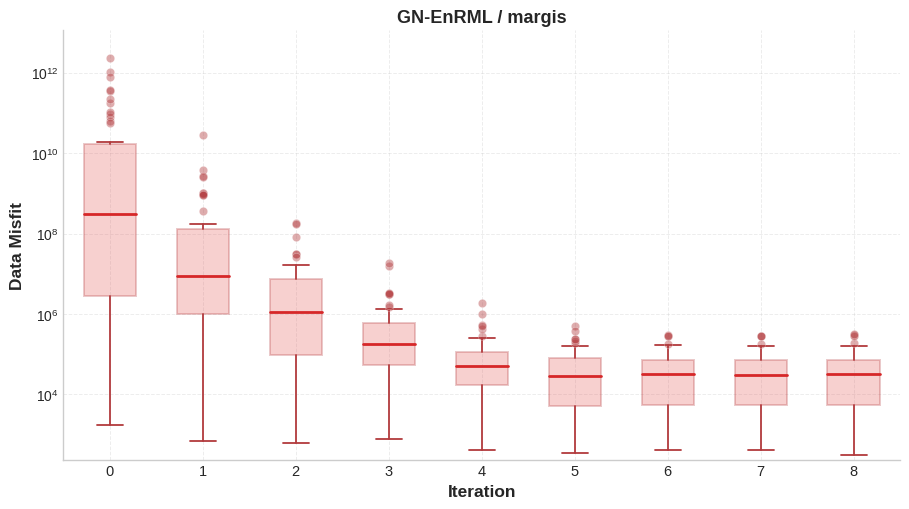

In [8]:
result_folder = "Results_margis"
data_misfit_gn = []

it = 0
while True:
    file = Path(f"{result_folder}/assimilation_result_{it}.npz")
    if not file.exists():
        break
    npzfile = np.load(file)
    data_misfit_gn.append(npzfile["ensemble_misfit"])
    it += 1

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9.2, 5.2), facecolor="white")
bp = ax.boxplot(
    data_misfit_gn,
    positions=range(len(data_misfit_gn)),
    widths=0.56,
    patch_artist=True,
    showfliers=True,
    boxprops=dict(facecolor="#E45756", alpha=0.28, linewidth=1.4, edgecolor="#B23A3D"),
    whiskerprops=dict(color="#B23A3D", linewidth=1.3),
    capprops=dict(color="#B23A3D", linewidth=1.3),
    medianprops=dict(color="#D62728", linewidth=2.0),
    flierprops=dict(marker="o", markersize=6, markerfacecolor="#B23A3D",
                    markeredgecolor="white", markeredgewidth=0.4, alpha=0.42),
)

positions = range(len(data_misfit_gn))
ax.set_xticks(positions)
ax.set_xticklabels([str(i) for i in positions], fontsize=10.5)
ax.set_xlabel("Iteration", fontsize=12.5, fontweight="semibold")
ax.set_ylabel("Data Misfit", fontsize=12.5, fontweight="semibold")
ax.set_yscale("log")
y_min = max(1e-12, np.nanmin([np.nanmin(s) for s in data_misfit_gn]) * 0.75)
y_max = np.nanmax([np.nanmax(s) for s in data_misfit_gn]) * 5
ax.set_ylim(y_min, y_max)
ax.grid(which="major", axis="both", linestyle="--", linewidth=0.7, alpha=0.35)
ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.45, alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("GN-EnRML / margis", fontsize=13, fontweight="semibold")
fig.tight_layout()
plt.show()


<font size=4em>Same two checks as for ESMDA: the permeability field itself, and the well rates it was conditioned on. `plot_field` is the exact function defined above -- reused as-is, only the ensemble it is called on changes. `prior_ensemble.npz` here is GN-EnRML's own prior draw, written fresh when its ensemble was built (a later, independent draw from ESMDA's, per the same prior distribution), not the one loaded from `Results/` above.


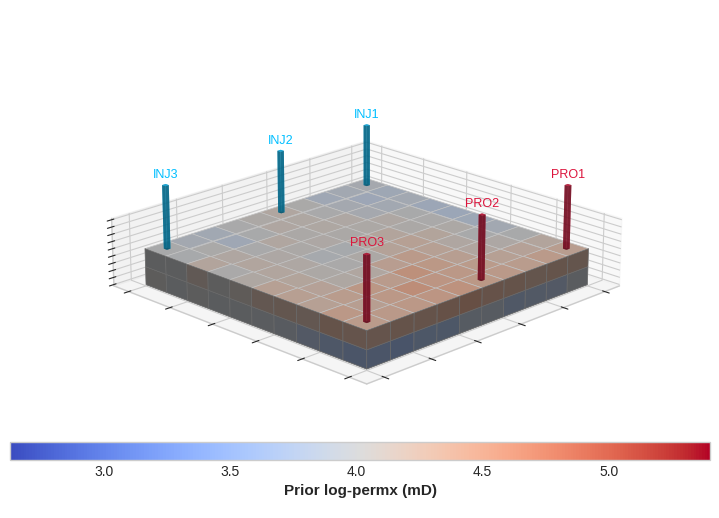

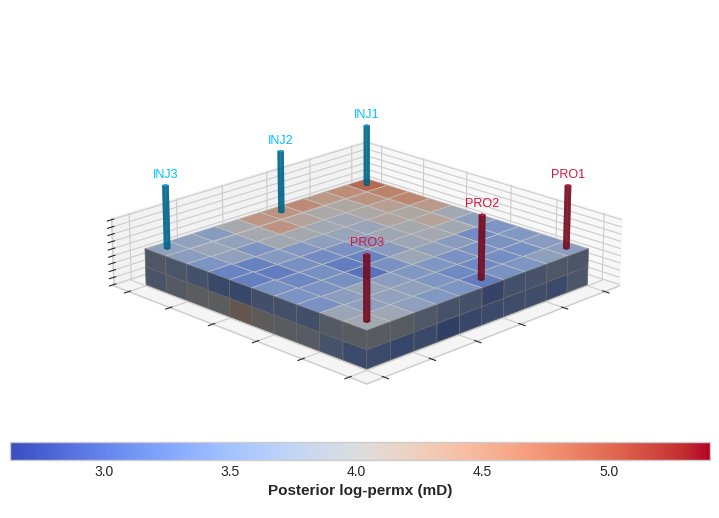

In [13]:
# Plot prior and posterior fields (mean of ensemble) for the GN-EnRML/margis run
prior_permx_gn = np.load('prior_ensemble.npz')['permx'].mean(axis=-1)
posterior_permx_gn = res_gn.x.mean(axis=-1)
cmax_gn = max(prior_permx_gn.max(), posterior_permx_gn.max())
cmin_gn = min(prior_permx_gn.min(), posterior_permx_gn.min())
plot_field(prior_permx_gn, label='Prior log-permx (mD)', cmapname='coolwarm', cmax=cmax, cmin=cmin)
plot_field(posterior_permx_gn, label='Posterior log-permx (mD)', cmapname='coolwarm', cmax=cmax, cmin=cmin)


<font size=4em>And the well rates, using `plot_rates` from above unchanged, reading `Results_margis`'s forecasts in place of `Results`'s:


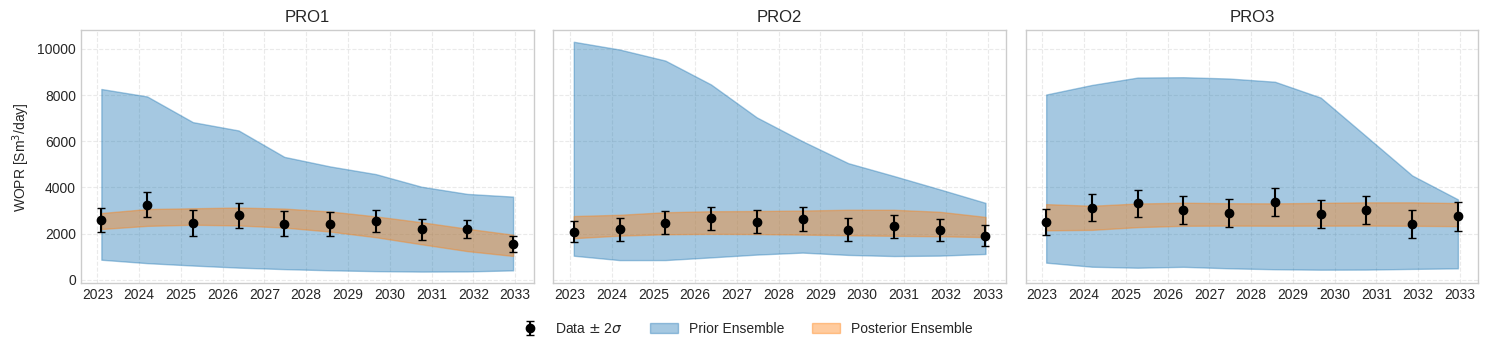

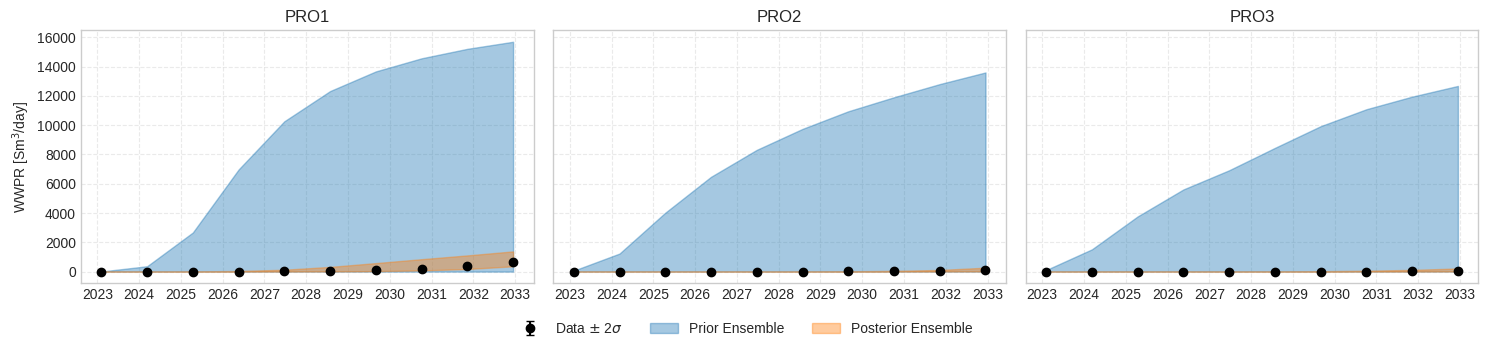

In [16]:
prior_forecast_gn = PETDataFrame.from_pickle("Results_margis/prior_forecast.pkl")
prior_forecast_gn.is_ensemble = True

posterior_forecast_gn = PETDataFrame.from_pickle("Results_margis/posterior_forecast.pkl")
posterior_forecast_gn.is_ensemble = True

plot_rates(
    data=data,
    std=std,
    prior=prior_forecast_gn,
    post=posterior_forecast_gn,
    key='WOPR',
)

plot_rates(
    data=data,
    std=std,
    prior=prior_forecast_gn,
    post=posterior_forecast_gn,
    key='WWPR',
)
